In [1]:
### Packages ###

import glob
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
### Calculation of pulse quantities from multiple ROOT folders and saving to Parquet ###

import glob
import uproot
import awkward as ak
import numpy as np

# Parent folder containing all run folders

base_folder = "/disk/gfs_atp/rhampp/Run6/MuonPanelOnly/"

run_folders = [
    "20260706_134125",
    "20260707_170158",
    "20260708_115549",
    "20260709_101823",
]

channels = ["wf0", "wf1", "wf2"]

# Dictionary to store all results

results = {}

for ch in channels:
    results[ch] = {
        "run": [],
        "baseline": [],
        "area": [],
        "amplitude": [],
        "nsamples": [],
        "integration_width": []
    }

# Loop over all run folders

for run_name in run_folders:

    folder = base_folder + run_name + "/"
    root_files = sorted(glob.glob(folder + "*.root"))

    print(f"\n===== Processing run folder: {run_name} =====")
    print(f"Found {len(root_files)} ROOT files")

    # Loop over all ROOT files in this folder

    for filename in root_files:

        print(f"Processing {filename}")

        data = uproot.open(filename)["dig_0"].arrays()

        # Loop over all events

        for event in range(len(data["wf0"])):

            # Loop over all channels

            for ch in channels:

                wf = np.array(data[ch][event])

                # 1. Calculate baseline
                baseline = np.mean(wf[:50])

                # 2. Define threshold for negative-going pulses
                threshold = baseline - 20

                # 3. Find samples below threshold
                indices = np.where(wf < threshold)[0]

                if len(indices) > 0:

                    # Integration window
                    start = max(0, indices[0] - 3)
                    stop = min(len(wf), indices[-1] + 4)

                    # Pulse quantities
                    area = np.sum(baseline - wf[start:stop])
                    amplitude = baseline - np.min(wf[start:stop])

                    # Additional quantities
                    nsamples = len(indices)
                    integration_width = stop - start

                else:

                    area = 0
                    amplitude = 0
                    nsamples = 0
                    integration_width = 0

                # Store quantities
                results[ch]["run"].append(run_name)
                results[ch]["baseline"].append(baseline)
                results[ch]["area"].append(area)
                results[ch]["amplitude"].append(amplitude)
                results[ch]["nsamples"].append(nsamples)
                results[ch]["integration_width"].append(integration_width)

# Convert lists to NumPy arrays

for ch in channels:
    for key in results[ch]:
        results[ch][key] = np.array(results[ch][key])

# Convert to an Awkward Array

output = ak.Array({
    "wf0": {
        "run": results["wf0"]["run"],
        "baseline": results["wf0"]["baseline"],
        "area": results["wf0"]["area"],
        "amplitude": results["wf0"]["amplitude"],
        "nsamples": results["wf0"]["nsamples"],
        "integration_width": results["wf0"]["integration_width"],
    },
    "wf1": {
        "run": results["wf1"]["run"],
        "baseline": results["wf1"]["baseline"],
        "area": results["wf1"]["area"],
        "amplitude": results["wf1"]["amplitude"],
        "nsamples": results["wf1"]["nsamples"],
        "integration_width": results["wf1"]["integration_width"],
    },
    "wf2": {
        "run": results["wf2"]["run"],
        "baseline": results["wf2"]["baseline"],
        "area": results["wf2"]["area"],
        "amplitude": results["wf2"]["amplitude"],
        "nsamples": results["wf2"]["nsamples"],
        "integration_width": results["wf2"]["integration_width"],
    }
})

# Save to Parquet

ak.to_parquet(output, "outputfile_muon1and2.parquet")

print("Results written to outputfile_muon1and2.parquet")

In [2]:
### Load processed data from parquet file ###

data = ak.from_parquet("/home/uzh/brkoch/outputfile_muon1and2.parquet")

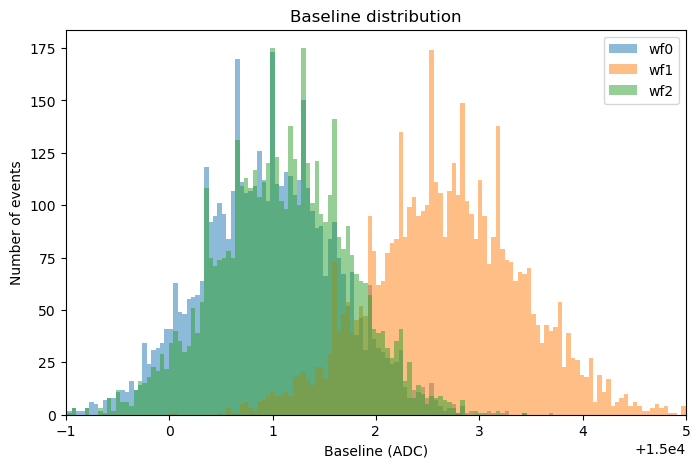

In [9]:
### A. Plot baseline distribution ###

# Access baselines
baselines0 = np.array(data["wf0"]["baseline"])
baselines1 = np.array(data["wf1"]["baseline"])
baselines2 = np.array(data["wf2"]["baseline"])

# Determine common range
xmin = min(baselines0.min(), baselines1.min(), baselines2.min())
xmax = max(baselines0.max(), baselines1.max(), baselines2.max())

# Create common bins
bins = np.linspace(xmin, xmax, 161)

plt.figure(figsize=(8, 5))

plt.hist(baselines0, bins=bins, alpha=0.5, label="wf0")
plt.hist(baselines1, bins=bins, alpha=0.5, label="wf1")
plt.hist(baselines2, bins=bins, alpha=0.5, label="wf2")

plt.xlim(14999, 15005)

plt.xlabel("Baseline (ADC)")
plt.ylabel("Number of events")
plt.title("Baseline distribution")
plt.legend()

plt.show()

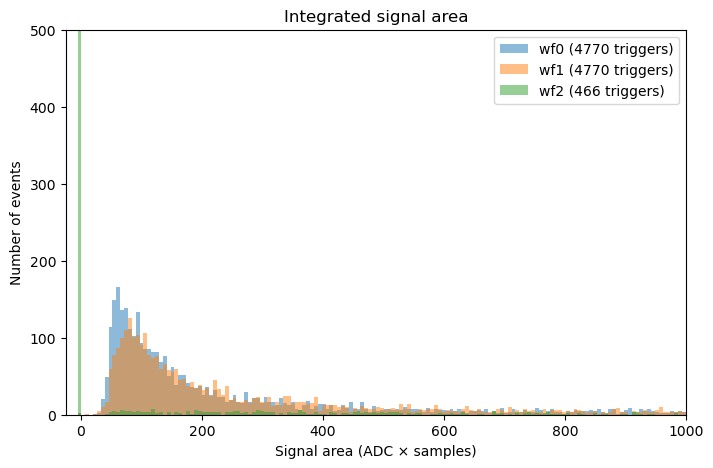

In [12]:
### B. i. Plot histograms of integrated signal areas ###

# Access pulse areas
areas0 = np.array(data["wf0"]["area"])
areas1 = np.array(data["wf1"]["area"])
areas2 = np.array(data["wf2"]["area"])

# Count triggers = events with non-zero pulse area
trigger0 = np.sum(areas0 > 0)
trigger1 = np.sum(areas1 > 0)
trigger2 = np.sum(areas2 > 0)

# Create common bins
bins = np.linspace(-25, 1000, 161)

plt.figure(figsize=(8, 5))

plt.hist(areas0, bins=bins, alpha=0.5,
         label=f"wf0 ({trigger0} triggers)")
plt.hist(areas1, bins=bins, alpha=0.5,
         label=f"wf1 ({trigger1} triggers)")
plt.hist(areas2, bins=bins, alpha=0.5,
         label=f"wf2 ({trigger2} triggers)")

plt.xlim(-25, 1000)
plt.ylim(0, 500)

plt.xlabel("Signal area (ADC × samples)")
plt.ylabel("Number of events")
plt.title("Integrated signal area")
plt.legend()

plt.show()

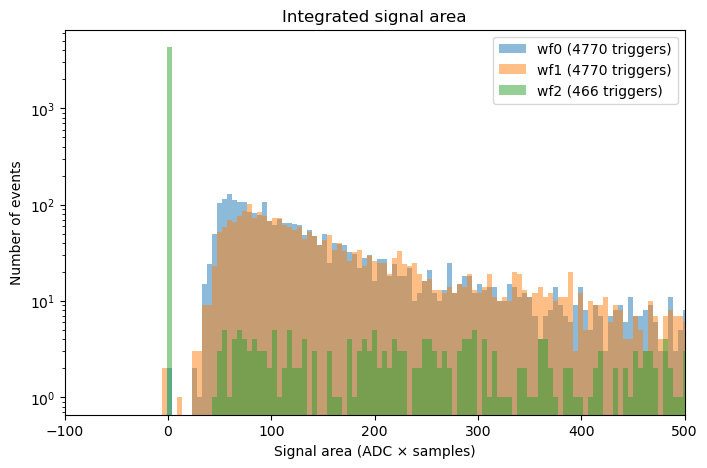

In [18]:
### B. ii. Plot histograms of integrated signal areas with log scale ###

# Access pulse areas
areas0 = np.array(data["wf0"]["area"])
areas1 = np.array(data["wf1"]["area"])
areas2 = np.array(data["wf2"]["area"])

# Count triggers = events with non-zero pulse area
trigger0 = np.sum(areas0 > 0)
trigger1 = np.sum(areas1 > 0)
trigger2 = np.sum(areas2 > 0)

# Create common bins
bins = np.linspace(-25, 750, 161)

plt.figure(figsize=(8, 5))

plt.hist(areas0, bins=bins, alpha=0.5,
         label=f"wf0 ({trigger0} triggers)")
plt.hist(areas1, bins=bins, alpha=0.5,
         label=f"wf1 ({trigger1} triggers)")
plt.hist(areas2, bins=bins, alpha=0.5,
         label=f"wf2 ({trigger2} triggers)")

plt.yscale("log")

plt.xlim(-100, 500)

plt.xlabel("Signal area (ADC × samples)")
plt.ylabel("Number of events")
plt.title("Integrated signal area")
plt.legend()

plt.show()

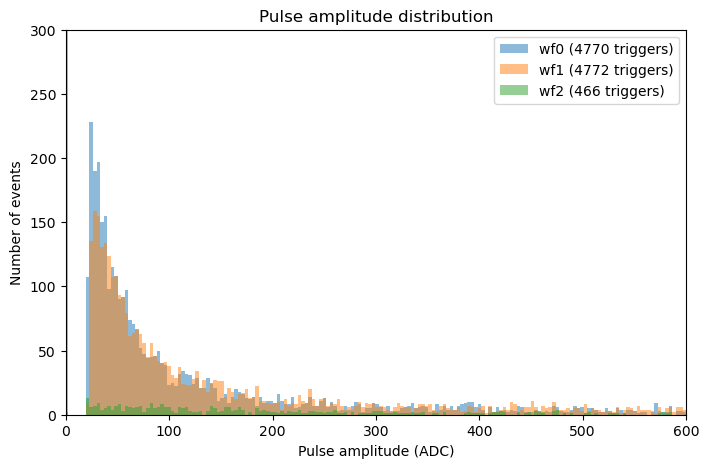

In [24]:
### C. i. Plot peak amplitude (pulse height) ###

# Access pulse amplitudes
amplitudes0 = np.array(data["wf0"]["amplitude"])
amplitudes1 = np.array(data["wf1"]["amplitude"])
amplitudes2 = np.array(data["wf2"]["amplitude"])

# Count events with a detected pulse (amplitude > 0)
trigger0 = np.sum(amplitudes0 > 0)
trigger1 = np.sum(amplitudes1 > 0)
trigger2 = np.sum(amplitudes2 > 0)

# Create common bins
bins = np.linspace(-25, 1000, 301)

plt.figure(figsize=(8, 5))

plt.hist(amplitudes0, bins=bins, alpha=0.5,
         label=f"wf0 ({trigger0} triggers)")
plt.hist(amplitudes1, bins=bins, alpha=0.5,
         label=f"wf1 ({trigger1} triggers)")
plt.hist(amplitudes2, bins=bins, alpha=0.5,
         label=f"wf2 ({trigger2} triggers)")

plt.xlim(0, 600)
plt.ylim(0, 300)

plt.xlabel("Pulse amplitude (ADC)")
plt.ylabel("Number of events")
plt.title("Pulse amplitude distribution")
plt.legend()

plt.show()

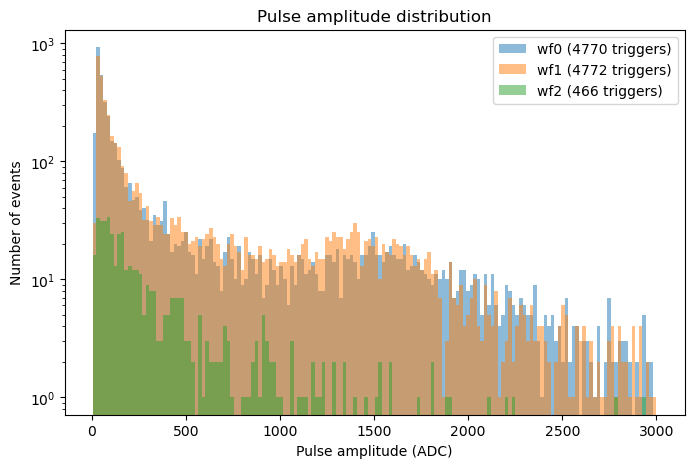

In [8]:
### C. ii. Plot peak amplitude (pulse height) with logarithmic y-axis ###

# Access pulse amplitudes
amplitudes0 = np.array(data["wf0"]["amplitude"])
amplitudes1 = np.array(data["wf1"]["amplitude"])
amplitudes2 = np.array(data["wf2"]["amplitude"])

# Count events with a detected pulse (amplitude > 0)
trigger0 = np.sum(amplitudes0 > 0)
trigger1 = np.sum(amplitudes1 > 0)
trigger2 = np.sum(amplitudes2 > 0)

# Create common bins
bins = np.linspace(5, 3000, 161)

plt.figure(figsize=(8, 5))

plt.hist(amplitudes0, bins=bins, alpha=0.5,
         label=f"wf0 ({trigger0} triggers)")
plt.hist(amplitudes1, bins=bins, alpha=0.5,
         label=f"wf1 ({trigger1} triggers)")
plt.hist(amplitudes2, bins=bins, alpha=0.5,
         label=f"wf2 ({trigger2} triggers)")

plt.yscale("log")   # Logarithmic y-axis

plt.xlabel("Pulse amplitude (ADC)")
plt.ylabel("Number of events")
plt.title("Pulse amplitude distribution")
plt.legend()

plt.show()

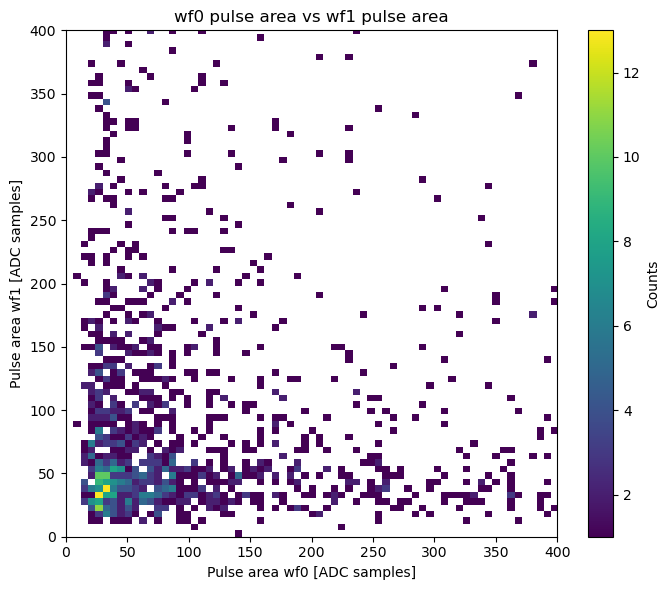

In [28]:
### D. Plot wf0 pulse area vs wf1 pulse area ###

# Extract pulse areas
area0 = ak.to_numpy(data["wf0"]["area"])
area1 = ak.to_numpy(data["wf1"]["area"])

# Optional: remove events with no pulse in one of the channels
mask = (area0 > 0) & (area1 > 0)

area0 = area0[mask]
area1 = area1[mask]

# Plot
plt.figure(figsize=(7, 6))

plt.hist2d(
    area0,
    area1,
    bins=2000,
    range=[[0, np.percentile(area0, 99.5)],
           [0, np.percentile(area1, 99.5)]],
    cmap="viridis",
    cmin=1
)

plt.xlim(0, 400)
plt.ylim(0, 400)

plt.colorbar(label="Counts")
plt.xlabel("Pulse area wf0 [ADC samples]")
plt.ylabel("Pulse area wf1 [ADC samples]")
plt.title("wf0 pulse area vs wf1 pulse area")

plt.tight_layout()
plt.show()

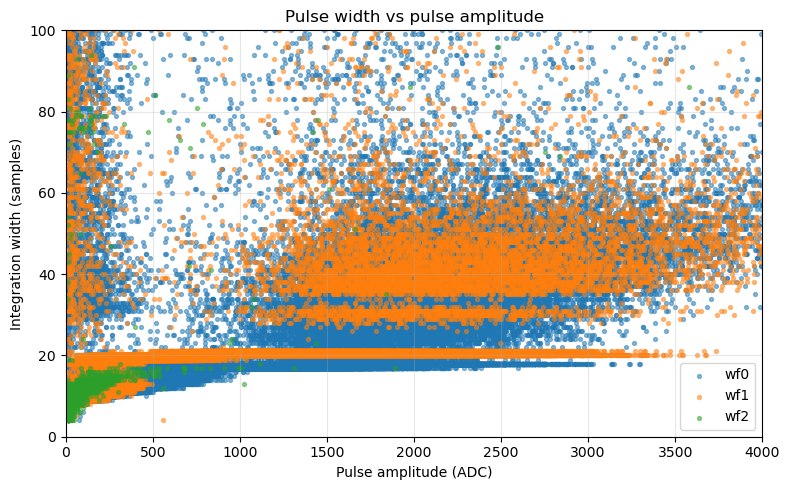

In [30]:
### E. Plot integration width vs pulse amplitude ###

channels = ["wf0", "wf1", "wf2"]

plt.figure(figsize=(8, 5))

for ch in channels:

    # Extract pulse amplitude and integration width
    amplitudes = np.asarray(
        ak.to_numpy(ak.flatten(data[ch]["amplitude"], axis=None)),
        dtype=float
    )

    widths = np.asarray(
        ak.to_numpy(ak.flatten(data[ch]["integration_width"], axis=None)),
        dtype=float
    )

    # Remove invalid values and events without a detected pulse
    mask = (
        np.isfinite(amplitudes)
        & np.isfinite(widths)
        & (amplitudes > 0)
        & (widths > 0)
    )

    amplitudes = amplitudes[mask]
    widths = widths[mask]

    plt.scatter(
        amplitudes,
        widths,
        s=8,
        alpha=0.5,
        label=ch
    )

plt.xlim(0, 4000)
plt.ylim(0, 100)

plt.xlabel("Pulse amplitude (ADC)")
plt.ylabel("Integration width (samples)")
plt.title("Pulse width vs pulse amplitude")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()